## Notebook creating the overlap of variants from exeter and 80K MPRA with effect sizes

In [27]:
import pandas as pd
import numpy as np
import os
import yaml
import re
import matplotlib.pyplot as plt
from importlib import reload


# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

### Helpful functions: 

In [28]:
# dict of chr number to refseq chromosome number
chrom_2_refseq = {"1": "NC_000001.11",
    "2": "NC_000002.12",
    "3": "NC_000003.12",
    "4": "NC_000004.12",
    "5": "NC_000005.10",
    "6": "NC_000006.12",
    "7": "NC_000007.14",
    "8": "NC_000008.11",
    "9": "NC_000009.12",
    "10": "NC_000010.11",
    "11": "NC_000011.10",
    "12": "NC_000012.12",
    "13": "NC_000013.11",
    "14": "NC_000014.9",
    "15": "NC_000015.10",
    "16": "NC_000016.10",
    "17": "NC_000017.11",
    "18": "NC_000018.10",
    "19": "NC_000019.10",
    "20": "NC_000020.11",
    "21": "NC_000021.9",
    "22": "NC_000022.11",
    "X": "NC_000023.11",
    "Y": "NC_000024.10"}

# get args with click: input file, seperator, ids of chr, pos, ref, alt in string

def create_speedy_chromosomes(user_string, seperator="-", indices=[0,1,2,3]):
    """
    Returns SPDI identifier for given variant
    spdi: refseq_chromosome:pos:ref:alt
    @params: indices: list of indices for chromosome, position, ref and alt in user_string
    """
    if len(user_string.split(seperator)) < 4:
        raise ValueError('Not enough indices given: Expected chrom, pos, ref, alt position in user_string')
    split_string = user_string.split(seperator)
    zero_based_position = int(split_string[indices[1]]) - 1 # (input: 1-based => 0-based)
    return f'{chrom_2_refseq[split_string[indices[0]]]}:{zero_based_position}:{split_string[indices[2]]}:{split_string[indices[3]]}'


### Read Data: 
#### Total overlap of exeter data 
- create common SPDI format variant id

In [29]:
# read file in is ';' /home/kisa/coding/80K_MPRA/exeter/kilian_ALL_results.csv
exeter_results = pd.read_csv('/home/kisa/coding/80K_MPRA/exeter/kilian_ALL_results.csv', sep=";", low_memory=False)

# columns like A1FREQ, BETA, SE, CHISQ, LOG10P habe "," but are actually floats (german format)
# convert them to float
exeter_results['A1FREQ'] = exeter_results['A1FREQ'].apply(lambda x: x.replace(',', '.')).astype(float)
exeter_results['BETA'] = exeter_results['BETA'].apply(lambda x: x.replace(',', '.')).astype(float)
exeter_results['SE'] = exeter_results['SE'].apply(lambda x: x.replace(',', '.')).astype(float)
exeter_results['CHISQ'] = exeter_results['CHISQ'].apply(lambda x: x.replace(',', '.')).astype(float)
exeter_results['LOG10P'] = exeter_results['LOG10P'].apply(lambda x: x.replace(',', '.')).astype(float)
exeter_results['SPDI'] = exeter_results['ID'].apply(lambda x: create_speedy_chromosomes(x, seperator=":", indices=[0,1,2,3]))

exeter_results # 4602
unique_exeter_variants = exeter_results["SPDI"].nunique()
print(f'Number of unique variants in Exeter results: {unique_exeter_variants}')
# print(f'Number of unique variants in Exeter results: {exeter_results["ID"].nunique()}') # 4142 (not unique)

# show duplicates
# exeter_results[exeter_results.duplicated(subset='SPDI', keep=False)].sort_values('SPDI')



Number of unique variants in Exeter results: 4143


In [4]:
# plot histogram of A1FREQ
# exeter_results.hist(column='A1FREQ', bins=200)
# exeter_results.hist(column='N', bins=100)

#### Read overlap with COJO 

In [30]:
overlap_COJO_path = '/home/kisa/coding/80K_MPRA/exeter/kilian_COJO_results.xlsx'
MPRA_overlap_COJO = pd.read_excel(overlap_COJO_path)
MPRA_overlap_COJO

# processing: adding SPDI column
MPRA_overlap_COJO['SPDI'] = MPRA_overlap_COJO['SNP'].apply(lambda x: create_speedy_chromosomes(x, seperator=":", indices=[0,1,2,3]))
unique_COJO_variants = MPRA_overlap_COJO['SPDI'].nunique()
print('Number of unique SNPs in MPRA_overlap_COJO:', unique_COJO_variants)

Number of unique SNPs in MPRA_overlap_COJO: 7


#### Read bbmap standard mapq35 from MPRAsnakeflow (10.09.2024)
##### Variant Data: 
- get only tested variants (BCalm)
- get variant position and create SPDI format ALT
- ID of variant table is not unique (ALT is)


In [63]:
# variant_table_bbmap_35 = config['files']['creating']['mprasnakeflow_resequencing_bbmap35_variant_table']
# variant_table_bbmap_35_df = pd.read_csv(variant_table_bbmap_35, sep="\t", low_memory=False)
# variant_table_bbmap_35_df = pd.read_csv(variant_table_bbmap_35, sep="\t", low_memory=False)
# variant_table_bbmap_35_df = variant_table_bbmap_35_df.loc[variant_table_bbmap_35_df['ID'].str.startswith('cardiac_neuro_cava_random')]

variant_map = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t", low_memory=False, header=None)
variant_map.columns = ['ID', 'Region', 'REF', 'ALT']
variant_map
# bcalm results bbmap:
# input_file_bcalm = '/home/kisa/coding/80K_MPRA/bc_MPRAlm_results/results/toptable_new_filtering_variant_controls_mendelian_NGN2.tsv'
input_file_bcalm = config['files']['creating']['bc_MPRAlm']
bcalm_variant = pd.read_csv(input_file_bcalm, sep="\t", low_memory=False)
bcalm_variant
if bcalm_variant.shape[0] != bcalm_variant['variant_id'].nunique():
    raise ValueError('Not all variants are unique in bc_MPRAlm results')
if variant_map.shape[0] != variant_map['ID'].nunique():
    raise ValueError('Not all variants are unique in variant_map results')

# only tested:
tested_bcalm_variant = bcalm_variant.loc[bcalm_variant['variant_id'].str.contains('cardiac_neuro_cava_random')]
print(f"Number of tested variants in bc_MPRAlm: {tested_bcalm_variant.shape[0]}")
print(f"Number of unique tested variants in bc_MPRAlm: {tested_bcalm_variant['variant_id'].nunique()}")

print(f'Tested variants with bc_MPRAlm: {tested_bcalm_variant.shape[0]}')
print(f'Significant tested variants with bc_MPRAlm: {tested_bcalm_variant.loc[tested_bcalm_variant["adj.P.Val"] < 0.05].shape[0]}')

# get chrom pos ref alt pattern
tested_bcalm_variant['chr_pos_ref_alt'] = tested_bcalm_variant['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)
tested_bcalm_variant.loc[tested_bcalm_variant['chr_pos_ref_alt'] == "NA"]
# get SPDI
tested_bcalm_variant['SPDI'] = tested_bcalm_variant['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))
tested_bcalm_variant

# load element bc_MPRAlm results and add to the tested_bcalm_variant
columns_of_interest_bcalm = ['SPDI', 'logFC', 'adj.P.Val']
tested_bcalm_variant = tested_bcalm_variant[columns_of_interest_bcalm]
tested_bcalm_variant.columns = ['SPDI', 'variant_BCalm_logFC', 'variant_BCalm_adj.P.Val']


Number of tested variants in bc_MPRAlm: 37994
Number of unique tested variants in bc_MPRAlm: 37994
Tested variants with bc_MPRAlm: 37994
Significant tested variants with bc_MPRAlm: 814


/tmp/ipykernel_205632/2389748768.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcalm_variant['chr_pos_ref_alt'] = tested_bcalm_variant['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)
/tmp/ipykernel_205632/2389748768.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcalm_variant['SPDI'] = tested_bcalm_variant['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))


In [32]:
duplicated_variant_ids_variant_table_bcalm = tested_bcalm_variant[tested_bcalm_variant.duplicated(subset='SPDI', keep=False)].sort_values('SPDI') # 28
duplicated_variant_ids_variant_table_bcalm

,SPDI,variant_bcalm_logFC,variant_bcalm_adj.P.Val


In [8]:
# # duplicated variant ids:
# duplicated_variant_ids_variant_table = variant_table_bbmap_35_df[variant_table_bbmap_35_df.duplicated(subset='ID', keep=False)].sort_values('ID') # 28
# # duplicated_variant_ids_variant_table.to_csv('duplicated_variant_table_ID_bbmap_28.tsv', sep="\t", index=None) # 28
# # get chrom pos ref alt pattern
# duplicated_variant_ids_variant_table['chr_pos_ref_alt'] = duplicated_variant_ids_variant_table['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
# # get SPDI
# duplicated_variant_ids_variant_table['SPDI'] = duplicated_variant_ids_variant_table['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))
# duplicated_variant_ids_variant_table

# # check overlap:
# overlap_bcalm_variant_table = pd.merge(tested_bcalm_variant, duplicated_variant_ids_variant_table, on='SPDI', how='inner')
# overlap_bcalm_variant_table

##### Read element results bcalm to check if log_FCs are the same


In [59]:
element_bcalm_df = pd.read_csv(config['files']['creating']['element_analysis_np_negative_neuron_vs_tested'], sep="\t", low_memory=False)
# rename columns variant_id => REF
element_bcalm_df = element_bcalm_df.rename(columns={'variant_id': 'REF', 'logFC': 'REF_BCalm_logFC'})

print(f"Number of unique variants in element_bcalm_df: {variant_map['ID'].nunique()}") # 46157 # 47044
print(f"Number of variants table: {variant_map.shape[0]}") # 46157 # 47044
# # read variant table
# variant_map = pd.read_csv(variant_table_bbmap_35, sep="\t", low_memory=False)
element_bcalm_variant_map = pd.merge(variant_map, element_bcalm_df, on='REF', how='inner')
print(element_bcalm_variant_map.shape[0]) # 37615 # 38931
element_bcalm_variant_map['ID'].nunique() # 37603

Number of unique variants in element_bcalm_df: 47044
Number of variants table: 47044
38931


38931

In [52]:
element_bcalm_variant_map.head()

,ID,Region,REF,ALT,REF_BCalm_logFC,AveExpr,t,P.Value,adj.P.Val
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.466017,-1.294094,0.623983,2.663823e-01,2.956824e-01
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.002283,-0.799643,8.415652,5.412526e-17,1.165155e-16
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-1.202983,1.867668,3.103006e-02,3.612171e-02
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-1.202983,1.867668,3.103006e-02,3.612171e-02
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449,-1.202983,1.867668,3.103006e-02,3.612171e-02


In [54]:
element_bcalm_variant_map.columns

Index(['ID', 'Region', 'REF', 'ALT', 'REF_BCalm_logFC', 'AveExpr', 't',
       'P.Value', 'adj.P.Val', 'chr_pos_ref_alt', 'SPDI'],
      dtype='object')

In [60]:
element_bcalm_variant_map['chr_pos_ref_alt'] = element_bcalm_variant_map['ALT'].apply(hf.get_chrom_pos_ref_alt_pattern)
element_bcalm_variant_map['SPDI'] = element_bcalm_variant_map['chr_pos_ref_alt'].apply(lambda x: create_speedy_chromosomes(x, seperator="-", indices=[0,1,2,3]))
columns_of_interest_elements = ['SPDI', 'ID', 'REF', 'ALT', 'REF_BCalm_logFC']

# subset of columns
element_bcalm_variant_map = element_bcalm_variant_map[columns_of_interest_elements]
element_bcalm_variant_map.head()

,SPDI,ID,REF,ALT,REF_BCalm_logFC
0,NC_000001.11:2192365:T:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.466017
1,NC_000001.11:2193141:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,0.002283
2,NC_000001.11:2197933:C:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449
3,NC_000001.11:2198006:C:G,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449
4,NC_000001.11:2198045:G:A,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,-0.375449


In [61]:
variant_map['REF'].nunique() # 18883
# upper limit of reference seuqeuences associated to a variant
element_bcalm_df.loc[element_bcalm_df['REF'].str.contains('REF_')]['REF'].nunique() # 15877

15877

In [68]:
variant_results_bcalm_unique_variants.columns

Index(['SPDI', 'ID', 'REF', 'ALT', 'REF_BCalm_logFC', 'variant_BCalm_logFC',
       'variant_BCalm_adj.P.Val'],
      dtype='object')

In [79]:
# combine variant results of bcalm and element analysis
variant_results_bcalm_unique_variants = pd.merge(element_bcalm_variant_map, tested_bcalm_variant, on='SPDI', how='inner')
variant_results_bcalm_unique_variants #37512
# remove unnecessary columns
variant_results_bcalm_unique_variants = variant_results_bcalm_unique_variants[['SPDI', 'variant_BCalm_logFC',
       'variant_BCalm_adj.P.Val', 'REF_BCalm_logFC']]
# rename the columns
variant_results_bcalm_unique_variants.columns = ['SPDI', 'variant_effect_BCalm_logFC',
       'variant_effect_BCalm_adj_p_Val', 'reference_activity_BCalm_logFC']

In [80]:
variant_results_bcalm_unique_variants.columns

Index(['SPDI', 'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_Val',
       'reference_activity_BCalm_logFC'],
      dtype='object')

### Investigate overlap with exeter results from Email
- 50000 uk biobank genes
- COJO results 

In [81]:
# merge using SPDI
# uk biobank 50000
exeter_bcalm_80K_merged_df = pd.merge(exeter_results, variant_results_bcalm_unique_variants, on='SPDI', how='inner') # 4318 # 3835
unique_exeter_bcalm_overlap = exeter_bcalm_80K_merged_df['SPDI'].nunique()
print(f"Number of unique exeter overlap: {unique_exeter_bcalm_overlap}")
# COJO:
COJO_bcalm_80K_merged_df = pd.merge(MPRA_overlap_COJO, variant_results_bcalm_unique_variants, on='SPDI', how='inner')
unique_COJO_bcalm_overlap = COJO_bcalm_80K_merged_df['SPDI'].nunique()
print(f"Unique COJO and bcalm overlap: {unique_COJO_bcalm_overlap}")


Number of unique exeter overlap: 3835
Unique COJO and bcalm overlap: 7


In [82]:
# proportion:
print(f"Proportion of exeter overlap: {unique_exeter_bcalm_overlap} ({round(unique_exeter_bcalm_overlap/unique_exeter_variants*100,2)}%)")

print(f"Proportion of COJO overlap: {unique_COJO_bcalm_overlap} ({round(unique_COJO_bcalm_overlap/unique_COJO_variants*100,2)}%)")

Proportion of exeter overlap: 3835 (92.57%)
Proportion of COJO overlap: 7 (100.0%)


In [83]:

# write to file
exeter_bcalm_80K_merged_df.to_csv(f'/home/kisa/coding/80K_MPRA/exeter/kilian_ALL_results_variant_effect_BCalm_{exeter_bcalm_80K_merged_df.shape[0]}.csv', sep="\t", index=False)
COJO_bcalm_80K_merged_df.to_csv(f'/home/kisa/coding/80K_MPRA/exeter/kilian_COJO_results_variant_effect_BCalm_{COJO_bcalm_80K_merged_df.shape[0]}.csv', sep="\t", index=False)

In [91]:
exeter_bcalm_80K_merged_df # old: 4199 currently: 4318 # with ref and variant effect: 4274

# check if row has na values:
# exeter_bcalm_80K_merged_df['variant_effect_BCalm_adj_p_Val'].isna().sum() # 0
# exeter_bcalm_80K_merged_df['variant_effect_BCalm_logFC'].isna().sum() # 0
# exeter_bcalm_80K_merged_df['reference_activity_BCalm_logFC'].isna().sum() # 0

,order,protein,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,Passes_coverage_qc,SPDI,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_Val,reference_activity_BCalm_logFC
0,2882,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,1.322230,0.007755,29072.800000,6315.400000,NaN,No,NC_000003.12:46576011:T:C,-0.019196,0.962592,-0.019764
1,2884,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.047399,0.034882,1.846420,0.758951,NaN,No,NC_000003.12:46576011:T:C,-0.019196,0.962592,-0.019764
2,2883,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.041486,0.035039,1.401850,0.626325,NaN,No,NC_000003.12:46576011:T:C,-0.019196,0.962592,-0.019764
3,2886,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.031325,0.034860,0.807507,0.433140,NaN,No,NC_000003.12:46576011:T:C,-0.019196,0.962592,-0.019764
4,2885,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.031294,0.034880,0.804943,0.432245,NaN,No,NC_000003.12:46576011:T:C,-0.019196,0.962592,-0.019764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4269,3665,kcnh2,7:150902822:C:T,C,T,0.007675,38958,ADD,0.000230,0.040684,0.000032,0.001966,NaN,No,NC_000007.14:150902821:C:T,0.153010,0.591985,-0.149792
4270,1041,nrxn3,14:78958034:T:C,T,C,0.122962,38955,ADD,0.000042,0.010880,0.000015,0.001331,NaN,No,NC_000014.9:78958033:T:C,0.028297,0.931002,0.106843
4271,1803,cdh2,18:27942861:T:C,T,C,0.000022,46603,ADD,0.002136,0.634066,0.000011,0.001169,NaN,Yes,NC_000018.10:27942860:T:C,0.210965,0.048485,0.099112
4272,2037,izumo1,19:48781672:C:G,C,G,0.547754,38604,ADD,-0.000023,0.007071,0.000010,0.001107,NaN,No,NC_000019.10:48781671:C:G,0.113389,0.773584,0.158191


In [74]:
COJO_bcalm_80K_merged_df

,protein,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,Passes_coverage_qc,SPDI,REF_BCalm_logFC,variant_BCalm_logFC,variant_BCalm_adj.P.Val
0,lefty2,1:225898438:G:T,225898438,T,0.176398,0.495737,0.008208,0.000000e+00,39747.2,0.176405,0.476740,0.012991,8.141640e-295,-0.145228,No,NC_000001.11:225898437:G:T,0.018413,0.022046,0.946818
1,pacs2,14:105293503:T:C,105293503,C,0.291986,0.177110,0.007622,1.957680e-119,38138.3,0.291956,0.177110,0.007676,8.480760e-118,0.000000,No,NC_000014.9:105293502:T:C,-0.612074,0.008995,0.988185
2,smad3,15:67039376:C:T,67039376,T,0.032069,0.569058,0.019620,5.887470e-185,38818.1,0.032066,0.452244,0.020766,3.707130e-105,0.209790,Yes,NC_000015.10:67039375:C:T,-0.203354,-0.030955,0.935575
3,smad3,15:67075368:A:C,67075368,C,0.464739,0.207914,0.006917,1.686520e-198,38914.0,0.464743,0.157013,0.008817,6.037780e-71,0.226580,Yes,NC_000015.10:67075367:A:C,0.104441,-0.081842,0.590238
4,itpa,20:3210559:G:T,3210559,T,0.214896,0.391193,0.008535,0.000000e+00,36637.7,0.214900,0.643384,0.011949,0.000000e+00,-0.152143,Yes,NC_000020.11:3210558:G:T,0.016969,0.085982,0.664404
5,rtn4r,22:20289425:C:A,20289425,A,0.142644,-0.037523,0.008887,2.420350e-05,46941.3,0.142643,-0.134958,0.010496,7.702160e-38,0.000000,No,NC_000022.11:20289424:C:A,-0.048336,-0.069582,0.837128
6,dnm1,9:128174338:G:C,128174338,C,0.337843,-0.230333,0.007337,2.363200e-216,39004.8,0.337834,-0.118165,0.009881,5.800510e-33,0.080302,Yes,NC_000009.12:128174337:G:C,0.280759,-0.042516,0.905845


In [44]:
MPRA_overlap_COJO

,protein,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r,Passes_coverage_qc,SPDI
0,lefty2,1:225898438:G:T,225898438,T,0.176398,0.495737,0.008208,0.000000e+00,39747.2,0.176405,0.476740,0.012991,8.141640e-295,-0.145228,No,NC_000001.11:225898437:G:T
1,pacs2,14:105293503:T:C,105293503,C,0.291986,0.177110,0.007622,1.957680e-119,38138.3,0.291956,0.177110,0.007676,8.480760e-118,0.000000,No,NC_000014.9:105293502:T:C
2,smad3,15:67039376:C:T,67039376,T,0.032069,0.569058,0.019620,5.887470e-185,38818.1,0.032066,0.452244,0.020766,3.707130e-105,0.209790,Yes,NC_000015.10:67039375:C:T
3,smad3,15:67075368:A:C,67075368,C,0.464739,0.207914,0.006917,1.686520e-198,38914.0,0.464743,0.157013,0.008817,6.037780e-71,0.226580,Yes,NC_000015.10:67075367:A:C
4,itpa,20:3210559:G:T,3210559,T,0.214896,0.391193,0.008535,0.000000e+00,36637.7,0.214900,0.643384,0.011949,0.000000e+00,-0.152143,Yes,NC_000020.11:3210558:G:T
5,rtn4r,22:20289425:C:A,20289425,A,0.142644,-0.037523,0.008887,2.420350e-05,46941.3,0.142643,-0.134958,0.010496,7.702160e-38,0.000000,No,NC_000022.11:20289424:C:A
6,dnm1,9:128174338:G:C,128174338,C,0.337843,-0.230333,0.007337,2.363200e-216,39004.8,0.337834,-0.118165,0.009881,5.800510e-33,0.080302,Yes,NC_000009.12:128174337:G:C


### Investigate the AF distribution

In [163]:
exeter_bcalm_80K_merged_df_activity.columns

Index(['order', 'protein', 'ID', 'ALLELE0', 'ALLELE1', 'A1FREQ', 'N', 'TEST',
       'BETA', 'SE', 'CHISQ', 'LOG10P', 'EXTRA', 'Passes_coverage_qc', 'SPDI',
       'variant_bcalm_logFC', 'variant_bcalm_adj.P.Val',
       'element_BCalm_logFC'],
      dtype='object')

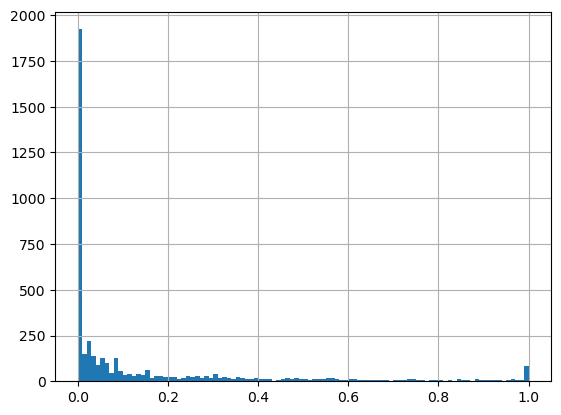

Number of common exeter variants: 2399


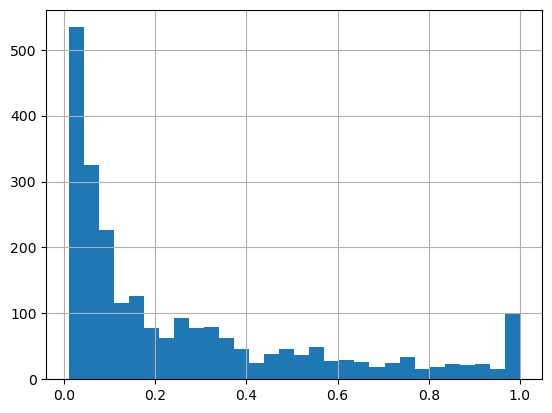

Number of rare exeter variants: 1923


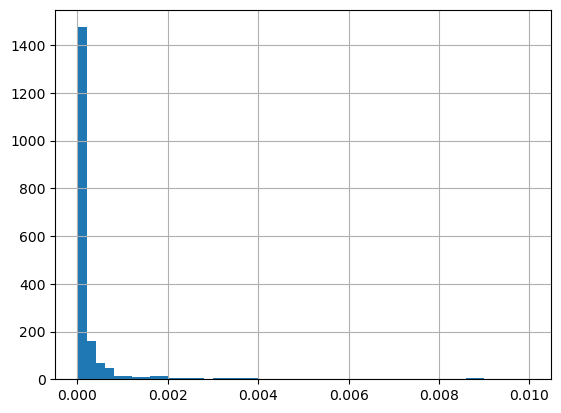

Proportion of common exeter variants: 2399 (0.56%)
Proportion of rare exeter variants: 1923 (0.44%)


In [164]:
# write exeter overlap:
exeter_bcalm_80K_merged_df_activity['A1FREQ'].hist(bins=100)
plt.show()

common_exeter = exeter_bcalm_80K_merged_df_activity.loc[exeter_bcalm_80K_merged_df_activity['A1FREQ'] > 0.01]
rare_exeter = exeter_bcalm_80K_merged_df_activity.loc[exeter_bcalm_80K_merged_df_activity['A1FREQ'] <= 0.01]

print(f"Number of common exeter variants: {common_exeter.shape[0]}")
common_exeter['A1FREQ'].hist(bins=30)
plt.show()

print(f"Number of rare exeter variants: {rare_exeter.shape[0]}")
rare_exeter['A1FREQ'].hist(bins=50)
plt.show()

# How many of the significant variants are common/rare?
print(f"Proportion of common exeter variants: {common_exeter.shape[0]} ({round(common_exeter.shape[0]/exeter_bcalm_80K_merged_df_activity.shape[0],2)}%)")

print(f"Proportion of rare exeter variants: {rare_exeter.shape[0]} ({round(rare_exeter.shape[0]/exeter_bcalm_80K_merged_df_activity.shape[0],2)}%)")

In [ ]:
# significant variants
significant_variants_exeter_overlap = exeter_bcalm_80K_merged_df_activity.loc[exeter_bcalm_80K_merged_df_activity['variant_bcalm_adj.P.Val'] < 0.05]


sig_common_exeter = significant_variants_exeter_overlap.loc[significant_variants_exeter_overlap['A1FREQ'] > 0.01]
sig_rare_exeter = significant_variants_exeter_overlap.loc[significant_variants_exeter_overlap['A1FREQ'] <= 0.01]
print(f"Number of common exeter variants: {sig_common_exeter.shape[0]}")
sig_common_exeter['A1FREQ'].hist(bins=30)
plt.show()

print(f"Number of rare exeter variants: {sig_rare_exeter.shape[0]}")
sig_rare_exeter['A1FREQ'].hist(bins=50)
plt.show()

# proportion between common and rare:
# How many of the common/rare variants are significant?
print(f"Proportion of significant varaint among common exeter variants: {sig_common_exeter.shape[0]} ({round(sig_common_exeter.shape[0]/common_exeter.shape[0],2)}%)")

print(f"Proportion of significant variants among rare exeter variants: {sig_rare_exeter.shape[0]} ({round(sig_rare_exeter.shape[0]/rare_exeter.shape[0],2)}%)")

# How many of the significant variants are common/rare?
print(f"Proportion of significant common exeter variants: {sig_common_exeter.shape[0]} ({round(sig_common_exeter.shape[0]/significant_variants_exeter_overlap.shape[0],2)}%)")

print(f"Proportion of significant rare exeter variants: {sig_rare_exeter.shape[0]} ({round(sig_rare_exeter.shape[0]/significant_variants_exeter_overlap.shape[0],2)}%)")

In [ ]:
# get dataframe of unique IDs of duplicates
duplicated_ids_exeter = exeter_results[exeter_results.duplicated(subset='SPDI', keep=False)].sort_values('SPDI')
duplicated_ids_exeter['is_duplicated'] = True
# make unique list of ids with is_duplicated flag
duplicated_ids_exeter[['ID', 'is_duplicated']].drop_duplicates().to_csv('/home/kisa/coding/80K_MPRA/exeter/duplicated_variants_in_overlap_exeter.csv', sep="\t", index=False)
# 71

### Write output 
- Overlap results table (variant effect + logFC_bcalm)
- Overlap results COJO (variant effect + logFC_bcalm)
- Duplicated variants table


In [105]:
# reaname the columns nicely: variant_effect_BCalm_logFC, variant_effect_BCalm_adj_p_val, reference_activity_BCalm_logFC
exeter_bcalm_80K_merged_df_activity_renamed = exeter_bcalm_80K_merged_df_activity.rename(columns={'variant_bcalm_logFC': 'variant_effect_BCalm_logFC', 'variant_bcalm_adj.P.Val': 'variant_effect_BCalm_adj_p_val', 'element_BCalm_logFC': 'reference_activity_BCalm_logFC'})
exeter_bcalm_80K_merged_df_activity_renamed

COJO_bcalm_80K_merged_df_activity_renamed = COJO_bcalm_80K_merged_df_activity.rename(columns={'variant_bcalm_logFC': 'variant_effect_BCalm_logFC', 'variant_bcalm_adj.P.Val': 'variant_effect_BCalm_adj_p_val', 'element_BCalm_logFC': 'reference_activity_BCalm_logFC'})
COJO_bcalm_80K_merged_df_activity_renamed

# drop SPDI
exeter_bcalm_80K_merged_df_activity_renamed = exeter_bcalm_80K_merged_df_activity_renamed.drop(columns=['SPDI'])
COJO_bcalm_80K_merged_df_activity_renamed = COJO_bcalm_80K_merged_df_activity_renamed.drop(columns=['SPDI'])

In [113]:
exeter_bcalm_80K_merged_df_activity_renamed

,order,protein,ID,ALLELE0,ALLELE1,A1FREQ,N,TEST,BETA,SE,CHISQ,LOG10P,EXTRA,Passes_coverage_qc,variant_effect_BCalm_logFC,variant_effect_BCalm_adj_p_val,reference_activity_BCalm_logFC
0,2882,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,1.322230,0.007755,29072.800000,6315.400000,NaN,No,-0.019194,0.961759,-0.109135
1,2884,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.047399,0.034882,1.846420,0.758951,NaN,No,-0.019194,0.961759,-0.109135
2,2883,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.041486,0.035039,1.401850,0.626325,NaN,No,-0.019194,0.961759,-0.109135
3,2886,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.031325,0.034860,0.807507,0.433140,NaN,No,-0.019194,0.961759,-0.109135
4,2885,tdgf1,3:46576012:T:C,T,C,0.244578,44589,ADD,0.031294,0.034880,0.804943,0.432245,NaN,No,-0.019194,0.961759,-0.109135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4317,3665,kcnh2,7:150902822:C:T,C,T,0.007675,38958,ADD,0.000230,0.040684,0.000032,0.001966,NaN,No,0.152990,0.590446,-0.169007
4318,1041,nrxn3,14:78958034:T:C,T,C,0.122962,38955,ADD,0.000042,0.010880,0.000015,0.001331,NaN,No,0.028297,0.929566,0.080725
4319,1803,cdh2,18:27942861:T:C,T,C,0.000022,46603,ADD,0.002136,0.634066,0.000011,0.001169,NaN,Yes,0.210980,0.048197,0.047469
4320,2037,izumo1,19:48781672:C:G,C,G,0.547754,38604,ADD,-0.000023,0.007071,0.000010,0.001107,NaN,No,0.113371,0.772495,0.178523


In [106]:
exeter_bcalm_80K_merged_df_activity_renamed.columns

Index(['order', 'protein', 'ID', 'ALLELE0', 'ALLELE1', 'A1FREQ', 'N', 'TEST',
       'BETA', 'SE', 'CHISQ', 'LOG10P', 'EXTRA', 'Passes_coverage_qc',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_val',
       'reference_activity_BCalm_logFC'],
      dtype='object')

In [107]:
COJO_bcalm_80K_merged_df_activity_renamed.columns

Index(['protein', 'SNP', 'bp', 'refA', 'freq', 'b', 'se', 'p', 'n',
       'freq_geno', 'bJ', 'bJ_se', 'pJ', 'LD_r', 'Passes_coverage_qc',
       'variant_effect_BCalm_logFC', 'variant_effect_BCalm_adj_p_val',
       'reference_activity_BCalm_logFC'],
      dtype='object')

In [111]:
# write to file
exeter_bcalm_80K_merged_df_activity_renamed.to_csv(f'/home/kisa/coding/80K_MPRA/exeter/kilian_ALL_results_variant_effect_BCalm_{exeter_bcalm_80K_merged_df_activity_renamed.shape[0]}.csv', sep="\t", index=False)
COJO_bcalm_80K_merged_df_activity_renamed.to_csv(f'/home/kisa/coding/80K_MPRA/exeter/kilian_COJO_results_variant_effect_BCalm_{COJO_bcalm_80K_merged_df_activity_renamed.shape[0]}.csv', sep="\t", index=False)